<a href="https://colab.research.google.com/github/tiaracantiq/gitgithub/blob/main/Implementation_of_xgboost_with_Recursive_Feature_Elimination_Method_for_Predicting_Arrhythmia_Heart_Disease_with_SMOTE_9_with_Tunning_Fix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -U scikit-learn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 35.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb # Added for XGBoost

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.svm import SVC
from sklearn.feature_selection import RFE

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import pandas as pd

# baca file CSV dengan delimiter titik-koma
df = pd.read_csv('/content/drive/MyDrive/Skripsi/Dataset/Penyakit_Jantung/data_aritmia.csv', sep=';')

# tampilkan ukuran dataset dan 5 baris awal
print(df.shape)
df.head()


(452, 280)


,age,sex,height,weight,qrs_duration,p-r_interval,q-t_interval,t_interval,p_interval,qrs,...,KY,KZ,LA,LB,LC,LD,LE,LF,LG,diagnosis
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0,-0.1,3.9,25.4,62.8,7


In [6]:
# Ensure 'target' column exists before using it
# This line is typically in cKnMhslhBxXq, but added here to resolve KeyError if state is transient
if 'target' not in df.columns:
    df['target'] = (df['diagnosis'] != 1).astype(int)

diagnosis_target_mapping = df.groupby('diagnosis')['target'].value_counts().unstack(fill_value=0)
print("Mapping of original 'diagnosis' values to 'target' (0=Normal, 1=Arrhythmia):")
display(diagnosis_target_mapping)

# Or, to just see the unique diagnosis values that resulted in target=0 vs target=1
diagnosis_for_target_0 = df[df['target'] == 0]['diagnosis'].unique()
diagnosis_for_target_1 = df[df['target'] == 1]['diagnosis'].unique()

print(f"\nOriginal 'diagnosis' values mapped to target 0 (Normal): {sorted(diagnosis_for_target_0)}")
print(f"Original 'diagnosis' values mapped to target 1 (Arrhythmia): {sorted(diagnosis_for_target_1)}")

Mapping of original 'diagnosis' values to 'target' (0=Normal, 1=Arrhythmia):


target,0,1
diagnosis,,
1,245,0
2,0,44
3,0,15
4,0,15
5,0,13
6,0,25
7,0,3
8,0,2
9,0,9



Original 'diagnosis' values mapped to target 0 (Normal): [np.int64(1)]
Original 'diagnosis' values mapped to target 1 (Arrhythmia): [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(14), np.int64(15), np.int64(16)]


Preproccessing

In [7]:
df = df.copy()
df = df.replace(['?', ' ', ''], np.nan)

for col in df.columns:
    if col != 'diagnosis':
        df[col] = pd.to_numeric(df[col], errors='coerce')

na_all = df.columns[df.isna().all()]
df = df.drop(columns=na_all)

for col in df.columns:
    if col != 'diagnosis' and df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

df['target'] = (df['diagnosis'] != 1).astype(int)

X = df.drop(columns=['diagnosis', 'target'])
y = df['target']

print("Jumlah fitur:", X.shape[1])
y.value_counts()


Jumlah fitur: 279


,count
target,
0,245
1,207


EDA

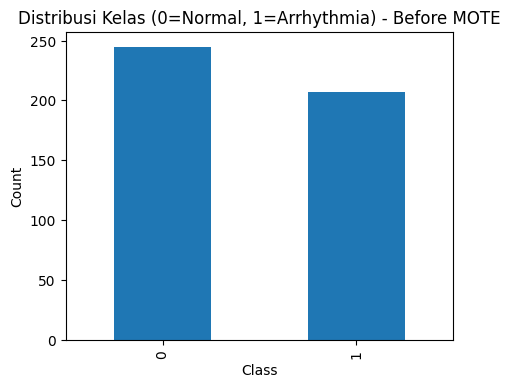

In [12]:
fig, ax = plt.subplots(figsize=(5,4))
y.value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title("Distribusi Kelas (0=Normal, 1=Arrhythmia) - Before MOTE")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()


### Arrhythmia Subtype Distribution

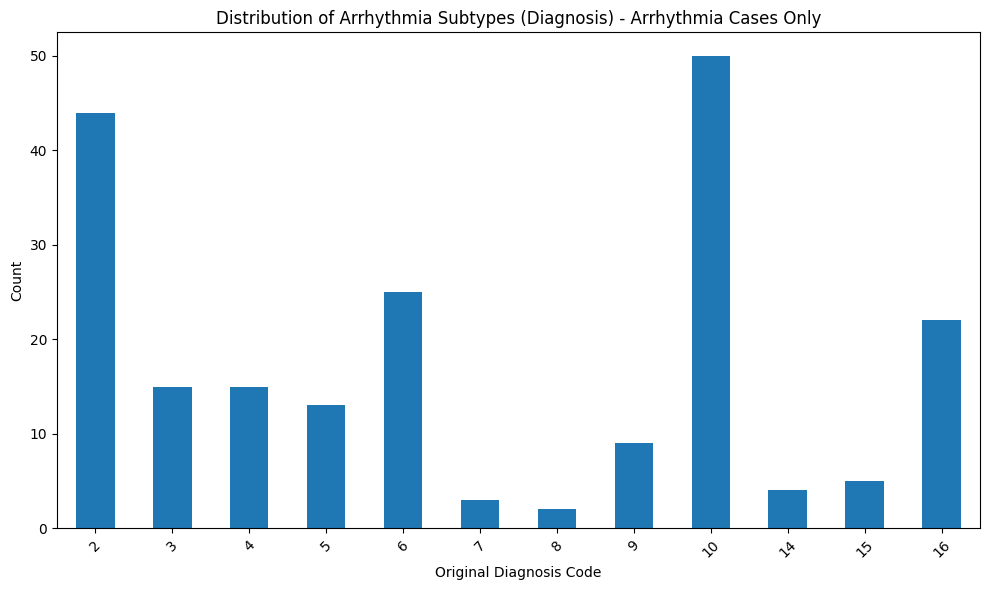

In [18]:
arrhythmia_cases = df[df['target'] == 1]

fig, ax = plt.subplots(figsize=(10, 6))
arrhythmia_cases['diagnosis'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title("Distribution of Arrhythmia Subtypes (Diagnosis) - Arrhythmia Cases Only")
ax.set_xlabel("Original Diagnosis Code")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

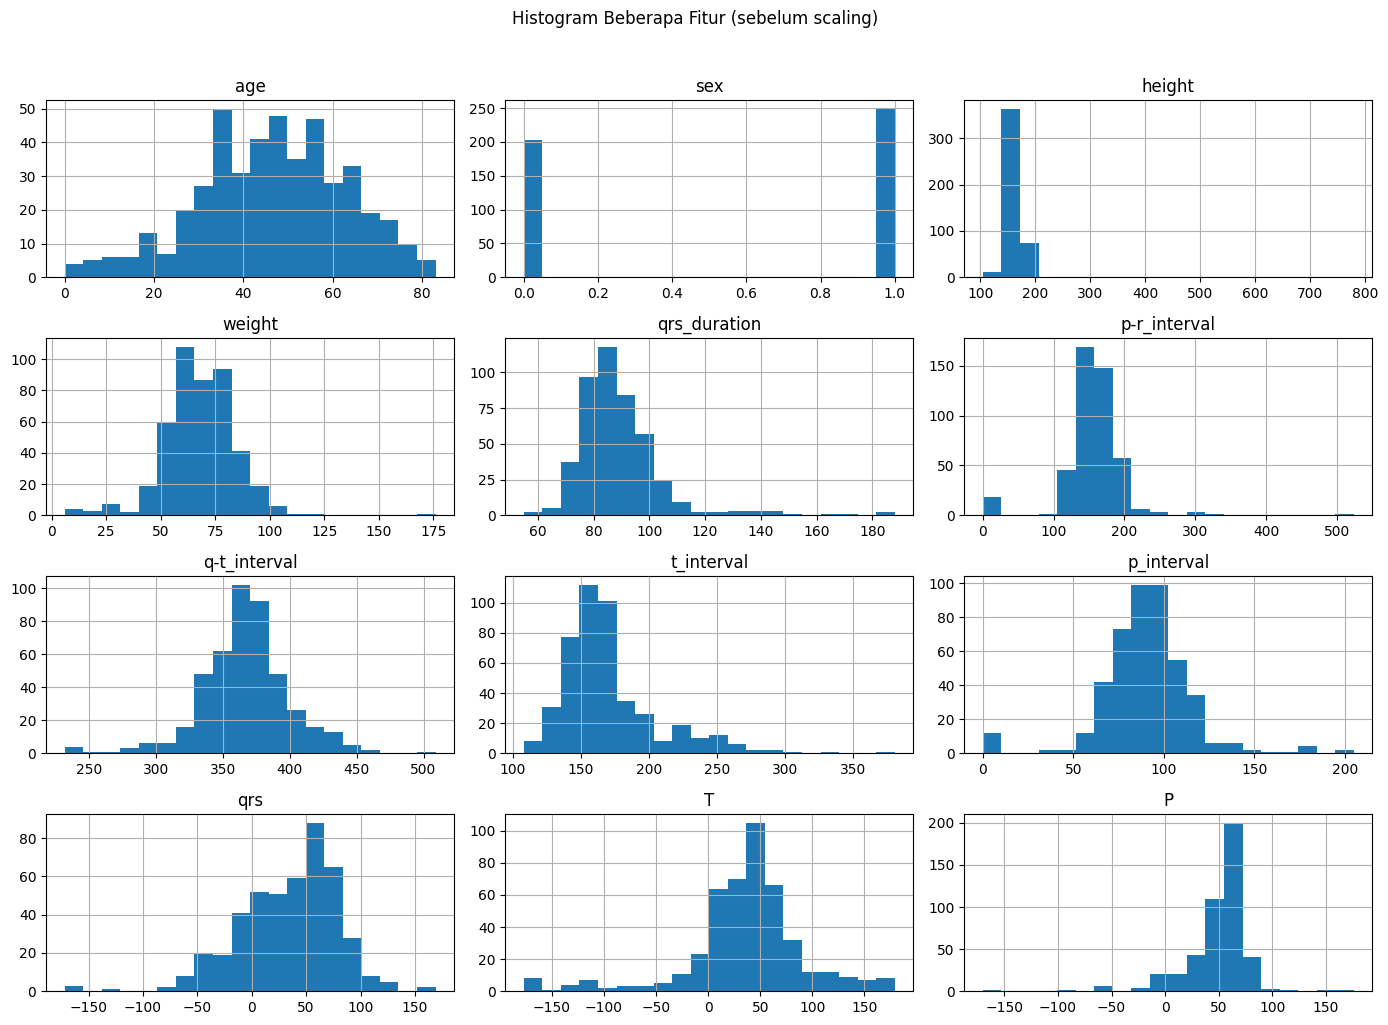

In [13]:
sample_cols = X.columns[:12]
X[sample_cols].hist(figsize=(14,10), bins=20)
plt.suptitle("Histogram Beberapa Fitur (sebelum scaling)", y=1.02)
plt.tight_layout()
plt.show()


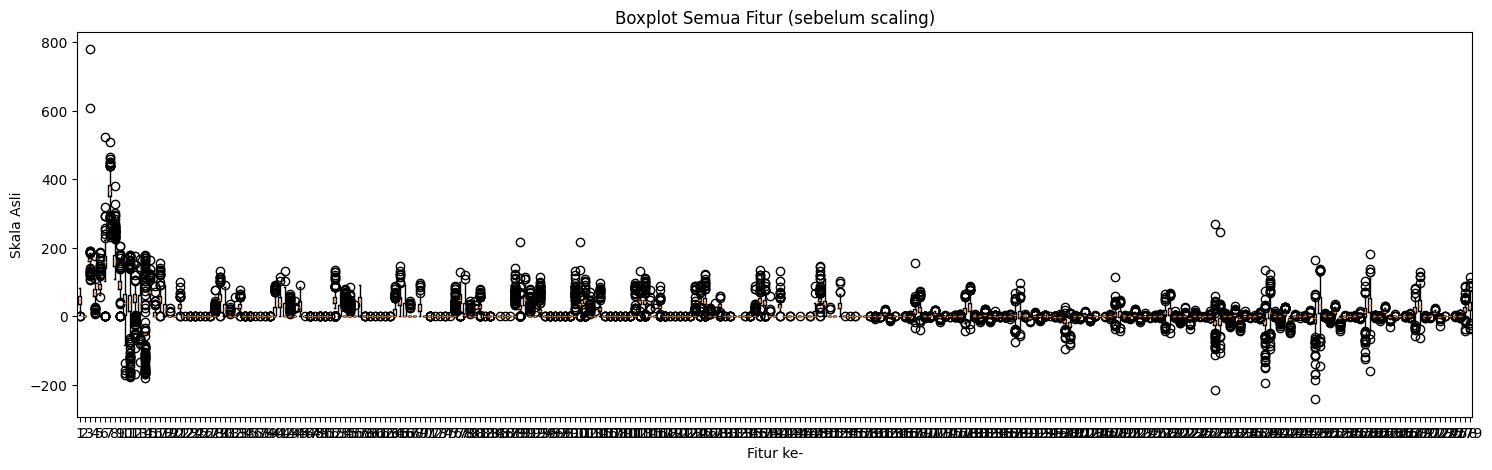

In [19]:
plt.figure(figsize=(18,5))
plt.boxplot(X.values, showfliers=True)
plt.title("Boxplot Semua Fitur (sebelum scaling)")
plt.xlabel("Fitur ke-")
plt.ylabel("Skala Asli")
plt.show()


/tmp/ipykernel_243/2300300881.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(before_smote.keys()), y=list(before_smote.values()), ax=axes[0], palette="Blues_d")
/tmp/ipykernel_243/2300300881.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(after_smote.keys()), y=list(after_smote.values()), ax=axes[1], palette="Greens_d")


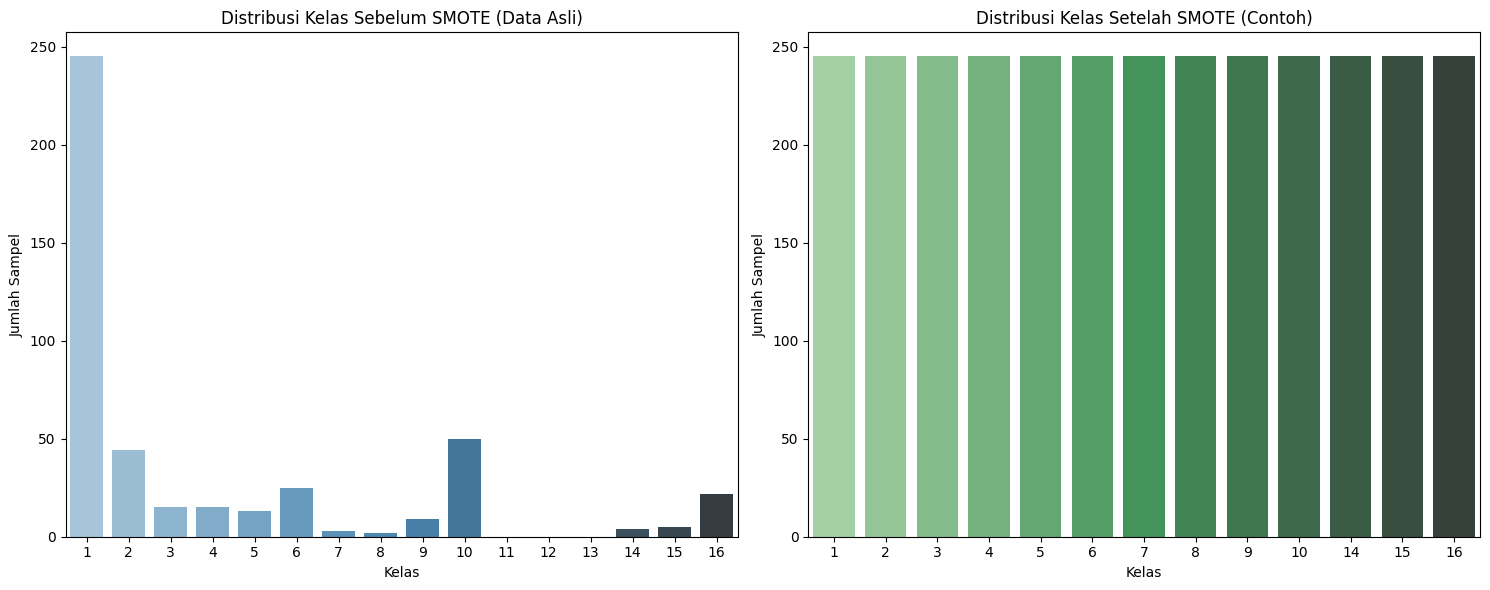

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Updated with the actual distribution provided by the user
before_smote = {
    1: 245, 2: 44, 3: 15, 4: 15, 5: 13, 6: 25,
    7: 3, 8: 2, 9: 9, 10: 50, 11: 0, 12: 0, 13: 0, 14: 4, 15: 5, 16: 22
}

# This remains an example of a perfectly balanced state after SMOTE
after_smote = {cls: 245 for cls in before_smote.keys() if before_smote[cls] > 0} # Only include classes that exist

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=list(before_smote.keys()), y=list(before_smote.values()), ax=axes[0], palette="Blues_d")
axes[0].set_title("Distribusi Kelas Sebelum SMOTE (Data Asli)")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Sampel")

sns.barplot(x=list(after_smote.keys()), y=list(after_smote.values()), ax=axes[1], palette="Greens_d")
axes[1].set_title("Distribusi Kelas Setelah SMOTE (Contoh)")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Jumlah Sampel")

plt.tight_layout()
plt.show()

In [21]:
def pick_safe_k_neighbors(y_train, base_k=5):
    """k_neighbors = min(base_k, min_count-1) agar SMOTE tidak error."""
    vc = pd.Series(y_train).value_counts()
    min_count = vc.min()
    return max(1, min(base_k, min_count - 1))


In [22]:
# Rumus normalisasi min-max: x_norm = (x - x_min) / (x_max - x_min)

# Define selected_features to fix the NameError
selected_features = X.columns[:5] # Using the first 5 columns of X for demonstration

# Pilih salah satu fitur dari 'selected_features' untuk contoh
col = selected_features[0] # Mengambil fitur pertama sebagai contoh

# Dapatkan nilai min dan max dari fitur tersebut di data asli (sebelum scaling)
x_min, x_max = X[col].min(), X[col].max()

# Ambil satu contoh nilai dari fitur tersebut
sample_val = X[col].iloc[0]

# Hitung nilai normalisasi manual
norm_val = (sample_val - x_min) / (x_max - x_min)

print(f"Contoh normalisasi kolom '{col}':")
print(f"Nilai asli: {sample_val:.2f}")
print(f"Rumus: (x - {x_min:.2f}) / ({x_max:.2f} - {x_min:.2f})")
print(f"Nilai normalisasi: {norm_val:.4f}")

Contoh normalisasi kolom 'age':
Nilai asli: 75.00
Rumus: (x - 0.00) / (83.00 - 0.00)
Nilai normalisasi: 0.9036


In [23]:
def eval_scores(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm_2x2(y_true, y_pred, title="Confusion Matrix", cmap="Blues", annot_color='white'):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    plt.figure(figsize=(5,4))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
                     xticklabels=[0,1], yticklabels=[0,1], vmin=0)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.yticks(rotation=0)
    plt.show()
    return cm

Split Data

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (361, 279)
Shape of y_train: (361,)
Shape of X_test: (91, 279)
Shape of y_test: (91,)


Scalling Data

In [26]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)

Shape of X_train_scaled: (361, 279)
Shape of X_test_scaled: (91, 279)


Handle Imbalance Data with SMOTE

In [27]:
k_neighbors = pick_safe_k_neighbors(y_train)
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Shape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)
print("\nClass distribution of y_train_resampled:")
print(y_train_resampled.value_counts())

Shape of X_train_resampled: (392, 279)
Shape of y_train_resampled: (392,)

Class distribution of y_train_resampled:
target
1    196
0    196
Name: count, dtype: int64


Feature Selection with RFE

In [29]:
from xgboost import XGBClassifier

# 1. Inisialisasi XGBClassifier sebagai estimator dasar untuk RFE
xgb_estimator = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# 2. Inisialisasi RFE dengan estimator XGBClassifier
# n_features_to_select=15 akan memilih 15 fitur teratas.
# Kita akan menambahkan 'age' dan 'sex' secara manual setelah RFE.
rfe_selector = RFE(estimator=xgb_estimator, n_features_to_select=15, step=1)

# 3. Fit RFE ke data pelatihan yang sudah di-SMOTE
rfe_selector.fit(X_train_resampled, y_train_resampled)

# 4. Simpan nama-nama fitur yang terpilih oleh RFE
rfe_selected_features = X_train_resampled.columns[rfe_selector.support_]

# 5. Tambahkan fitur 'age' dan 'sex' secara eksplisit
# Pastikan 'age' dan 'sex' memang ada di X_train_resampled.columns
manual_features_to_add = ['age', 'sex']

# Gabungkan fitur yang dipilih RFE dengan fitur manual, hindari duplikasi dan pertahankan urutan
selected_features = list(rfe_selected_features) # Konversi ke list agar bisa dimodifikasi
for feature in manual_features_to_add:
    if feature not in selected_features:
        selected_features.append(feature)

# Urutkan fitur untuk konsistensi (opsional)
selected_features.sort()

# 6. Transformasikan X_train_resampled dan X_test_scaled menggunakan fitur yang sudah digabungkan
X_train_selected = X_train_resampled[selected_features]
X_test_selected = X_test_scaled[selected_features]


# 7. Cetak jumlah fitur yang terpilih dan bentuk (shape) dari data
print(f"Jumlah fitur yang terpilih: {len(selected_features)}")
print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")
print("\nSelected features:")
print(selected_features)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:48:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:48:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:48:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:48:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Jumlah fitur yang terpilih: 17
Shape of X_train_selected: (392, 17)
Shape of X_test_selected: (91, 17)

Selected features:
['CJ', 'DN', 'DZ', 'GJ', 'HR', 'IH', 'IV', 'JB', 'JD', 'JZ', 'KD', 'KV', 'LE', 'age', 'heart_rate', 'qrs_duration', 'sex']


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:49:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:49:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:49:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Model Training (XGBoost Classifier)

In [32]:
# Inisialisasi XGBoost Classifier dengan parameter yang sama seperti RFE
model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Latih model menggunakan data pelatihan yang sudah diseleksi dan di-SMOTE
model.fit(X_train_selected, y_train_resampled)

print("Model XGBoost Classifier telah berhasil dilatih.")

Model XGBoost Classifier telah berhasil dilatih.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:54:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Model Evaluation

Metrik Evaluasi Model:
Accuracy: 0.8571
Precision: 0.8537
Recall: 0.8333
F1: 0.8434


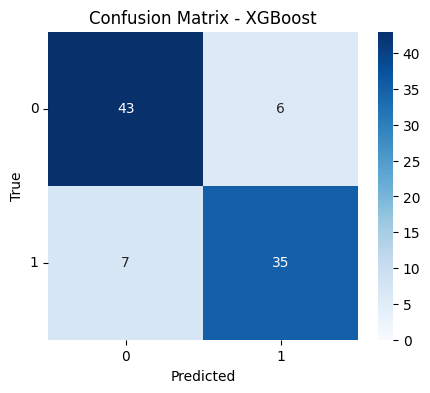

In [33]:
# Lakukan prediksi pada data uji yang sudah diseleksi
y_pred = model.predict(X_test_selected)

# Hitung dan tampilkan metrik evaluasi
metrics = eval_scores(y_test, y_pred)
print("Metrik Evaluasi Model:")
for metric, value in metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

# Tampilkan Confusion Matrix
cm = plot_cm_2x2(y_test, y_pred, title="Confusion Matrix - XGBoost")

Tuning

In [34]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

print("XGBoost parameter grid defined:")
print(param_grid)

XGBoost parameter grid defined:
{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.6, 0.8, 1.0]}


### Hyperparameter Tuning (GridSearchCV)

In [36]:
# Inisialisasi model XGBoost yang akan di-tuning
model_for_tuning = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Inisialisasi GridSearchCV
# Menggunakan StratifiedKFold untuk menjaga proporsi kelas di setiap lipatan cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=model_for_tuning,
    param_grid=param_grid,
    scoring='f1', # Menggunakan F1-score karena kita berhadapan dengan data yang mungkin tidak seimbang
    cv=kfold,
    n_jobs=-1, # Menggunakan semua core CPU yang tersedia
    verbose=2
)

# Latih GridSearchCV pada data pelatihan yang sudah diseleksi dan di-SMOTE
print("Memulai Grid Search untuk Hyperparameter Tuning...")
grid_search.fit(X_train_selected, y_train_resampled)

print("\nGrid Search Selesai.")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1-score: {grid_search.best_score_:.4f}")

# Simpan model terbaik
best_model = grid_search.best_estimator_

Memulai Grid Search untuk Hyperparameter Tuning...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Grid Search Selesai.
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best F1-score: 0.8439


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:58:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Model Evaluation After Tuning

Metrik Evaluasi Model (Setelah Tuning):
Accuracy: 0.8901
Precision: 0.9000
Recall: 0.8571
F1: 0.8780


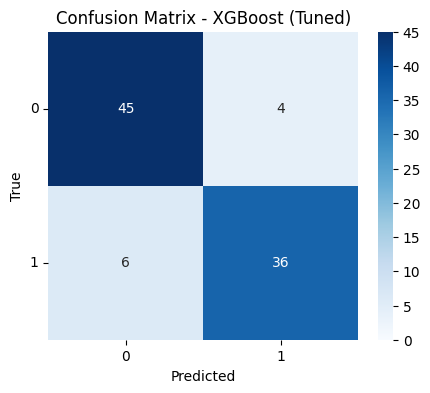

In [37]:
# Lakukan prediksi pada data uji menggunakan model terbaik
y_pred_tuned = best_model.predict(X_test_selected)

# Hitung dan tampilkan metrik evaluasi untuk model yang telah di-tuning
metrics_tuned = eval_scores(y_test, y_pred_tuned)
print("Metrik Evaluasi Model (Setelah Tuning):")
for metric, value in metrics_tuned.items():
    print(f"{metric.capitalize()}: {value:.4f}")

# Tampilkan Confusion Matrix untuk model yang telah di-tuning
cm_tuned = plot_cm_2x2(y_test, y_pred_tuned, title="Confusion Matrix - XGBoost (Tuned)")

Ealuate Untuned Model

In [40]:
y_pred = model.predict(X_test_selected) # Add this line to define y_pred

untuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
}

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1-Score": f1_score(y_test, y_pred_tuned),
}

comparison_df = pd.DataFrame({
    'Untuned XGBoost': untuned_metrics,
    'Tuned XGBoost': tuned_metrics
})

print("\nPerformance Comparison (Untuned vs. Tuned XGBoost):")
print(comparison_df.round(4))


Performance Comparison (Untuned vs. Tuned XGBoost):
           Untuned XGBoost  Tuned XGBoost
Accuracy            0.8571         0.8901
Precision           0.8537         0.9000
Recall              0.8333         0.8571
F1-Score            0.8434         0.8780


### Multi-class Classification: Predicting Arrhythmia Subtypes

In [44]:
# 1. Filter the original DataFrame to include only arrhythmia cases (target == 1)
df_arrhythmia = df[df['target'] == 1].copy()

# 2. Define features (X_multi) and target (y_multi) for multi-class classification
# We will use the same 17 selected features
X_multi = df_arrhythmia[selected_features]
y_multi = df_arrhythmia['diagnosis'] # Original 'diagnosis' column for subtypes

print(f"Shape of X_multi (arrhythmia cases with selected features): {X_multi.shape}")
print(f"Shape of y_multi (arrhythmia subtypes): {y_multi.shape}")
print("\nDistribution of arrhythmia subtypes:")
print(y_multi.value_counts())


Shape of X_multi (arrhythmia cases with selected features): (207, 17)
Shape of y_multi (arrhythmia subtypes): (207,)

Distribution of arrhythmia subtypes:
diagnosis
10    50
2     44
6     25
16    22
3     15
4     15
5     13
9      9
15     5
14     4
7      3
8      2
Name: count, dtype: int64


#### Data Splitting for Multi-class Model

In [45]:
# Split the multi-class data into training and testing sets
# Use stratify to maintain the proportion of each arrhythmia subtype
# Use a different random state to ensure this split is independent
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=100, stratify=y_multi
)

print(f"Shape of X_train_multi: {X_train_multi.shape}")
print(f"Shape of y_train_multi: {y_train_multi.shape}")
print(f"Shape of X_test_multi: {X_test_multi.shape}")
print(f"Shape of y_test_multi: {y_test_multi.shape}")

print("\nClass distribution in y_train_multi:")
print(y_train_multi.value_counts().sort_index())
print("\nClass distribution in y_test_multi:")
print(y_test_multi.value_counts().sort_index())


Shape of X_train_multi: (165, 17)
Shape of y_train_multi: (165,)
Shape of X_test_multi: (42, 17)
Shape of y_test_multi: (42,)

Class distribution in y_train_multi:
diagnosis
2     35
3     12
4     12
5     10
6     20
7      2
8      2
9      7
10    40
14     3
15     4
16    18
Name: count, dtype: int64

Class distribution in y_test_multi:
diagnosis
2      9
3      3
4      3
5      3
6      5
7      1
9      2
10    10
14     1
15     1
16     4
Name: count, dtype: int64


#### Scaling Data for Multi-class Model

In [46]:
# Apply the *same* MinMaxScaler fitted on the binary classification training data
# This ensures consistency in feature scaling across both models

# To address the ValueError: The scaler was fitted on 279 features (X_train),
# but X_train_multi and X_test_multi only contain 17 selected_features.
# We need to reconstruct full DataFrames with all 279 features (unscaled)
# for the corresponding rows from X_train_multi/X_test_multi,
# then scale them, and finally select only the selected_features.

# 1. Get the full unscaled data for X_train_multi and X_test_multi indices
#    from the original 'X' (which contains all 279 features before any selection)
X_train_multi_full_unscaled = X.loc[X_train_multi.index]
X_test_multi_full_unscaled = X.loc[X_test_multi.index]

# 2. Apply the 'scaler' (fitted on X_train, which had all 279 features)
#    to these full unscaled dataframes.
X_train_multi_scaled_full = scaler.transform(X_train_multi_full_unscaled)
X_test_multi_scaled_full = scaler.transform(X_test_multi_full_unscaled)

# 3. Convert back to DataFrame, retaining column names from 'X' and original indices
X_train_multi_scaled_full = pd.DataFrame(X_train_multi_scaled_full,
                                             columns=X.columns,
                                             index=X_train_multi.index)
X_test_multi_scaled_full = pd.DataFrame(X_test_multi_scaled_full,
                                            columns=X.columns,
                                            index=X_test_multi.index)

# 4. Now, select only the 'selected_features' from the fully scaled data
X_train_multi_scaled = X_train_multi_scaled_full[selected_features]
X_test_multi_scaled = X_test_multi_scaled_full[selected_features]

print(f"Shape of X_train_multi_scaled: {X_train_multi_scaled.shape}")
print(f"Shape of X_test_multi_scaled: {X_test_multi_scaled.shape}")

Shape of X_train_multi_scaled: (165, 17)
Shape of X_test_multi_scaled: (42, 17)


#### Handling Imbalance in Multi-class Data with SMOTE

In [47]:
from imblearn.over_sampling import SMOTE

# We need to adapt k_neighbors for multi-class SMOTE if some classes are very small
# For multi-class, SMOTE needs sufficient samples for each class
# We'll use a slightly different approach or a variant like SMOTE-ENN if simple SMOTE fails

# Check the minimum number of samples in any class in y_train_multi
min_class_count = y_train_multi.value_counts().min()

# If min_class_count is less than 2, SMOTE will fail. We need to handle this.
# For now, let's set k_neighbors to a safe value, e.g., 1, if classes are too small.
# Or, we can use a different oversampling strategy for multi-class if this fails.

# SMOTE requires n_neighbors <= min_class_count - 1. If min_class_count is 1, n_neighbors must be 0, which is invalid.
# Let's use `sampling_strategy='auto'` and handle potential errors.

# Adjust k_neighbors based on the smallest class in the training set
# SMOTE requires at least 6 samples to generate 5 neighbors

# Determine the smallest class size in the training set
safest_k = min_class_count - 1 if min_class_count > 1 else 0 # 0 will cause error, need better handling

if safest_k < 1:
    print("Warning: Some classes have too few samples for standard SMOTE. Using default or alternative strategy.")
    # If the smallest class has only 1 sample, SMOTE will fail. We might need to remove such classes
    # or use a different imblearn strategy that can handle very small classes.
    # For this exercise, let's proceed and if it fails, we'll re-evaluate.
    smote_multi = SMOTE(random_state=42, k_neighbors=1) # Fallback to k=1 if possible
else:
    smote_multi = SMOTE(random_state=42, k_neighbors=min(5, safest_k))


# Apply SMOTE to the multi-class training data
X_train_multi_resampled, y_train_multi_resampled = smote_multi.fit_resample(X_train_multi_scaled, y_train_multi)

print(f"Shape of X_train_multi_resampled: {X_train_multi_resampled.shape}")
print(f"Shape of y_train_multi_resampled: {y_train_multi_resampled.shape}")
print("\nClass distribution of y_train_multi_resampled:")
print(y_train_multi_resampled.value_counts().sort_index())


Shape of X_train_multi_resampled: (480, 17)
Shape of y_train_multi_resampled: (480,)

Class distribution of y_train_multi_resampled:
diagnosis
2     40
3     40
4     40
5     40
6     40
7     40
8     40
9     40
10    40
14    40
15    40
16    40
Name: count, dtype: int64


#### Training the Multi-class XGBoost Model

In [53]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the training labels
y_train_multi_resampled_encoded = label_encoder.fit_transform(y_train_multi_resampled)
# Transform the test labels (do not fit again)
y_test_multi_encoded = label_encoder.transform(y_test_multi)

# Get the number of unique classes after encoding
num_classes_multi = len(label_encoder.classes_)

model_multi = XGBClassifier(
    objective='multi:softmax', # or 'multi:softprob' for probabilities
    num_class=num_classes_multi,
    eval_metric='mlogloss', # Multi-class logloss is appropriate here
    use_label_encoder=False,
    random_state=42
)

# Train the multi-class model using the encoded labels
model_multi.fit(X_train_multi_resampled, y_train_multi_resampled_encoded)

print("Multi-class XGBoost Classifier for arrhythmia subtypes has been successfully trained.")
print(f"Original classes mapped: {label_encoder.classes_}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:06:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Multi-class XGBoost Classifier for arrhythmia subtypes has been successfully trained.
Original classes mapped: [ 2  3  4  5  6  7  8  9 10 14 15 16]


Evaluating the Multi-class Model


Multi-class Classification Report:
              precision    recall  f1-score   support

           2       0.70      0.78      0.74         9
           3       0.50      0.67      0.57         3
           4       0.50      0.67      0.57         3
           5       0.75      1.00      0.86         3
           6       0.71      1.00      0.83         5
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         0
           9       1.00      1.00      1.00         2
          10       0.71      0.50      0.59        10
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1
          16       0.50      0.25      0.33         4

    accuracy                           0.64        42
   macro avg       0.45      0.49      0.46        42
weighted avg       0.63      0.64      0.62        42

Multi-class Accuracy: 0.6429


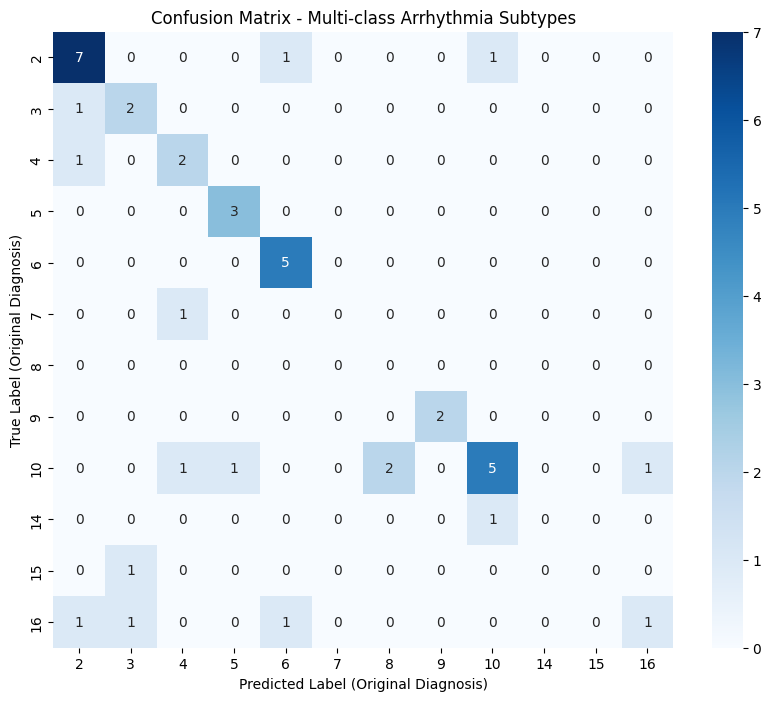

In [57]:
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predict on the multi-class test data (using encoded labels internally by the model)
y_pred_multi_encoded = model_multi.predict(X_test_multi_scaled)

# Evaluate the multi-class model using encoded true labels and predicted encoded labels
print("\nMulti-class Classification Report:")
# For classification report, we want to see metrics based on original labels if possible,
# but the report uses the encoded values. We can map the target_names to original labels.
# We use y_test_multi_encoded (true encoded labels) and y_pred_multi_encoded (predicted encoded labels)
print(classification_report(y_test_multi_encoded, y_pred_multi_encoded, zero_division=0, target_names=label_encoder.classes_.astype(str)))

print(f"Multi-class Accuracy: {accuracy_score(y_test_multi_encoded, y_pred_multi_encoded):.4f}")

# Generate and plot confusion matrix for multi-class
cm_multi = confusion_matrix(y_test_multi_encoded, y_pred_multi_encoded)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label (Original Diagnosis)')
plt.ylabel('True Label (Original Diagnosis)')
plt.title('Confusion Matrix - Multi-class Arrhythmia Subtypes')
plt.show()

Combined Prediction System for Website

In [58]:
def predict_arrhythmia_system(input_data_17_features):
    """
    Performs a two-step prediction: first binary (Normal/Arrhythmia), then multi-class (Arrhythmia Subtype).
    Input: A pandas Series or DataFrame with 17 features, matching `selected_features` order and names.
    Output: A dictionary indicating overall diagnosis and, if arrhythmia, the subtype.
    """
    # Ensure input data has the correct features and is scaled
    # 1. Create a DataFrame with all original 279 features, filled with a default value (e.g., 0)
    #    This ensures the input to the scaler has the correct number of columns.
    full_input_template = pd.DataFrame(0.0, index=[0], columns=X.columns)

    # 2. Populate the selected_features with the actual input data
    for feature in selected_features:
        full_input_template[feature] = input_data_17_features[feature]

    # 3. Scale the full input template using the *same* scaler fitted during training
    input_scaled_full = scaler.transform(full_input_template)

    # 4. Convert back to DataFrame and select only the required 17 features for the models
    input_scaled_df = pd.DataFrame(input_scaled_full, columns=X.columns).loc[:, selected_features]

    # Step 1: Binary Classification (Normal or Arrhythmia)
    binary_prediction = best_model.predict(input_scaled_df)[0]

    if binary_prediction == 0: # Predicted as Normal
        return {'Overall_Diagnosis': 'Normal', 'Arrhythmia_Subtype': 'N/A'}
    else: # Predicted as Arrhythmia
        # Step 2: Multi-class Classification (Arrhythmia Subtype)
        subtype_prediction_encoded = model_multi.predict(input_scaled_df)[0]
        # Inverse transform to get the original diagnosis code
        subtype_prediction_original = label_encoder.inverse_transform([subtype_prediction_encoded])[0]
        return {'Overall_Diagnosis': 'Arrhythmia', 'Arrhythmia_Subtype': int(subtype_prediction_original)}

print("Combined prediction system function `predict_arrhythmia_system` defined.")

Combined prediction system function `predict_arrhythmia_system` defined.


Example Usage of the Combined Prediction System

In [59]:
# To demonstrate, let's take a sample from the test set (an arrhythmia case)
# It's important to use the raw feature values before scaling for this example input,
# as the `predict_arrhythmia_system` function handles scaling internally.

# Example 1: A normal case from the original X_test (before selection/scaling)
# Find an actual normal case from the original X_test
normal_sample_idx = y_test[y_test == 0].index[0] # Get index of a normal case from the original test set
normal_sample_features = X_test.loc[normal_sample_idx, selected_features] # Get its 17 features

print("Prediction for a Normal Case:")
prediction_normal = predict_arrhythmia_system(normal_sample_features)
print(prediction_normal)


# Example 2: An arrhythmia case from the original X_test (before selection/scaling)
# Find an actual arrhythmia case from the original X_test
arrhythmia_sample_idx = y_test[y_test == 1].index[0] # Get index of an arrhythmia case from the original test set
arrhythmia_sample_features = X_test.loc[arrhythmia_sample_idx, selected_features] # Get its 17 features

print("\nPrediction for an Arrhythmia Case:")
prediction_arrhythmia = predict_arrhythmia_system(arrhythmia_sample_features)
print(prediction_arrhythmia)

# You can use `df['diagnosis'].value_counts()` to see the actual meaning of the subtype numbers.


Prediction for a Normal Case:
{'Overall_Diagnosis': 'Arrhythmia', 'Arrhythmia_Subtype': 10}

Prediction for an Arrhythmia Case:
{'Overall_Diagnosis': 'Arrhythmia', 'Arrhythmia_Subtype': 16}


### Hyperparameter Tuning for Multi-class XGBoost (GridSearchCV)

In [60]:
param_grid_multi = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

# Inisialisasi model XGBoost yang akan di-tuning (multi-class)
model_multi_for_tuning = XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes_multi, # Use the previously determined number of classes
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42
)

# Inisialisasi GridSearchCV
kfold_multi = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_multi = GridSearchCV(
    estimator=model_multi_for_tuning,
    param_grid=param_grid_multi,
    scoring='f1_weighted', # Use weighted F1-score for multi-class imbalanced data
    cv=kfold_multi,
    n_jobs=-1, # Use all available CPU cores
    verbose=2
)

# Latih GridSearchCV pada data pelatihan multi-kelas yang sudah di-SMOTE dan di-encode
print("Memulai Grid Search untuk Hyperparameter Tuning Model Multi-kelas...")
grid_search_multi.fit(X_train_multi_resampled, y_train_multi_resampled_encoded)

print("\nGrid Search Multi-kelas Selesai.")
print(f"Best parameters untuk model multi-kelas: {grid_search_multi.best_params_}")
print(f"Best F1-score (weighted) untuk model multi-kelas: {grid_search_multi.best_score_:.4f}")

# Simpan model terbaik multi-kelas
best_model_multi = grid_search_multi.best_estimator_


Memulai Grid Search untuk Hyperparameter Tuning Model Multi-kelas...
Fitting 5 folds for each of 81 candidates, totalling 405 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:20:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Grid Search Multi-kelas Selesai.
Best parameters untuk model multi-kelas: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
Best F1-score (weighted) untuk model multi-kelas: 0.9254


### Model Evaluation After Tuning (Multi-class)


Multi-class Classification Report (Setelah Tuning):
              precision    recall  f1-score   support

           2       0.70      0.78      0.74         9
           3       0.50      0.67      0.57         3
           4       0.67      0.67      0.67         3
           5       0.75      1.00      0.86         3
           6       0.71      1.00      0.83         5
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         0
           9       1.00      1.00      1.00         2
          10       0.70      0.70      0.70        10
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1
          16       1.00      0.25      0.40         4

    accuracy                           0.69        42
   macro avg       0.50      0.51      0.48        42
weighted avg       0.68      0.69      0.66        42

Multi-class Accuracy (Setelah Tuning): 0.6905


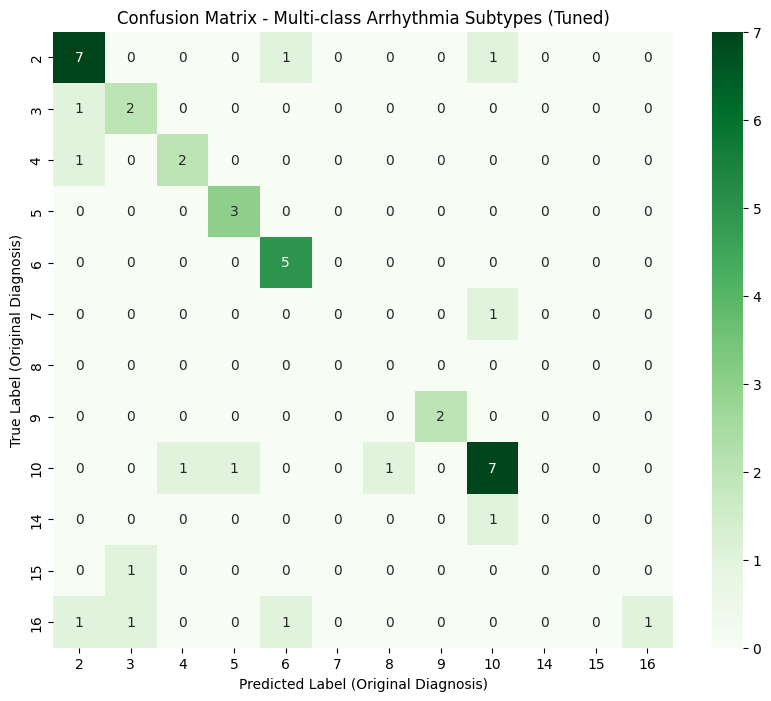

In [61]:
# Lakukan prediksi pada data uji multi-kelas menggunakan model terbaik
y_pred_multi_tuned_encoded = best_model_multi.predict(X_test_multi_scaled)

# Evaluasi model multi-kelas yang telah di-tuning
print("\nMulti-class Classification Report (Setelah Tuning):")
print(classification_report(y_test_multi_encoded, y_pred_multi_tuned_encoded, zero_division=0, target_names=label_encoder.classes_.astype(str)))

print(f"Multi-class Accuracy (Setelah Tuning): {accuracy_score(y_test_multi_encoded, y_pred_multi_tuned_encoded):.4f}")

# Tampilkan Confusion Matrix untuk model multi-kelas yang telah di-tuning
cm_multi_tuned = confusion_matrix(y_test_multi_encoded, y_pred_multi_tuned_encoded)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label (Original Diagnosis)')
plt.ylabel('True Label (Original Diagnosis)')
plt.title('Confusion Matrix - Multi-class Arrhythmia Subtypes (Tuned)')
plt.show()


### Update Combined Prediction System with Tuned Multi-class Model

In [70]:
def predict_arrhythmia_system_tuned(input_data_17_features):
    """
    Performs a two-step prediction with tuned models: first binary (Normal/Arrhythmia),
    then multi-class (Arrhythmia Subtype).
    Input: A pandas Series or DataFrame with 17 features, matching `selected_features` order and names.
    Output: A dictionary indicating overall diagnosis and, if arrhythmia, the subtype (name).
    """
    # 1. Create a DataFrame with all original 279 features, filled with a default value (e.g., 0)
    full_input_template = pd.DataFrame(0.0, index=[0], columns=X.columns)

    # 2. Populate the selected_features with the actual input data
    for feature in selected_features:
        full_input_template[feature] = input_data_17_features[feature]

    # 3. Scale the full input template using the *same* scaler fitted during training
    input_scaled_full = scaler.transform(full_input_template)

    # 4. Convert back to DataFrame and select only the required 17 features for the models
    input_scaled_df = pd.DataFrame(input_scaled_full, columns=X.columns).loc[:, selected_features]

    # Step 1: Binary Classification (Normal or Arrhythmia) using the TUNED binary model
    binary_prediction = best_model.predict(input_scaled_df)[0]

    if binary_prediction == 0: # Predicted as Normal
        return {'Overall_Diagnosis': diagnosis_names[1], 'Arrhythmia_Subtype': 'N/A'}
    else: # Predicted as Arrhythmia
        # Step 2: Multi-class Classification (Arrhythmia Subtype) using the TUNED multi-class model
        subtype_prediction_encoded = best_model_multi.predict(input_scaled_df)[0]
        # Inverse transform to get the original diagnosis code
        subtype_prediction_original_code = label_encoder.inverse_transform([subtype_prediction_encoded])[0]
        # Map the code to the diagnosis name
        subtype_name = diagnosis_names.get(subtype_prediction_original_code, f"Unknown Subtype (Code: {subtype_prediction_original_code})")
        return {'Overall_Diagnosis': 'Arrhythmia', 'Arrhythmia_Subtype': subtype_name}

print("Combined prediction system function `predict_arrhythmia_system_tuned` defined, using tuned models and diagnosis names.")

Combined prediction system function `predict_arrhythmia_system_tuned` defined, using tuned models and diagnosis names.


#### Example Usage of the Tuned Combined Prediction System

In [71]:
# Example 1: A normal case from the original X_test
print("Prediction for a Normal Case (using tuned models):")
prediction_normal_tuned = predict_arrhythmia_system_tuned(normal_sample_features)
print(prediction_normal_tuned)

# Example 2: An arrhythmia case from the original X_test
print("\nPrediction for an Arrhythmia Case (using tuned models):")
prediction_arrhythmia_tuned = predict_arrhythmia_system_tuned(arrhythmia_sample_features)
print(prediction_arrhythmia_tuned)


Prediction for a Normal Case (using tuned models):
{'Overall_Diagnosis': 'Arrhythmia', 'Arrhythmia_Subtype': 'Right bundle branch block'}

Prediction for an Arrhythmia Case (using tuned models):
{'Overall_Diagnosis': 'Arrhythmia', 'Arrhythmia_Subtype': 'Others'}


Perbandingan Performa Model Multi-kelas (Untuned vs. Tuned)

In [64]:
# Hitung metrik untuk model multi-kelas yang belum di-tuning
y_pred_multi_untuned_encoded = model_multi.predict(X_test_multi_scaled)

untuned_multi_metrics = {
    "Accuracy": accuracy_score(y_test_multi_encoded, y_pred_multi_untuned_encoded),
    "Precision (Weighted)": precision_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
    "Recall (Weighted)": recall_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
    "F1-Score (Weighted)": f1_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
}

# Metrik untuk model multi-kelas yang sudah di-tuning (sudah dihitung di cell sebelumnya)
tuned_multi_metrics = {
    "Accuracy": accuracy_score(y_test_multi_encoded, y_pred_multi_tuned_encoded),
    "Precision (Weighted)": precision_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
    "Recall (Weighted)": recall_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
    "F1-Score (Weighted)": f1_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
}

comparison_multi_df = pd.DataFrame({
    'Untuned Multi-class XGBoost': untuned_multi_metrics,
    'Tuned Multi-class XGBoost': tuned_multi_metrics
})

print("\nPerformance Comparison (Untuned vs. Tuned Multi-class XGBoost):")
print(comparison_multi_df.round(4))



Performance Comparison (Untuned vs. Tuned Multi-class XGBoost):
                      Untuned Multi-class XGBoost  Tuned Multi-class XGBoost
Accuracy                                   0.6429                     0.6905
Precision (Weighted)                       0.6253                     0.6815
Recall (Weighted)                          0.6429                     0.6905
F1-Score (Weighted)                        0.6194                     0.6591


Perbandingan Performa Model Multi-kelas (Untuned vs. Tuned)

In [65]:
# Hitung metrik untuk model multi-kelas yang belum di-tuning
y_pred_multi_untuned_encoded = model_multi.predict(X_test_multi_scaled)

untuned_multi_metrics = {
    "Accuracy": accuracy_score(y_test_multi_encoded, y_pred_multi_untuned_encoded),
    "Precision (Weighted)": precision_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
    "Recall (Weighted)": recall_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
    "F1-Score (Weighted)": f1_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
}

# Metrik untuk model multi-kelas yang sudah di-tuning (sudah dihitung di cell sebelumnya)
tuned_multi_metrics = {
    "Accuracy": accuracy_score(y_test_multi_encoded, y_pred_multi_tuned_encoded),
    "Precision (Weighted)": precision_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
    "Recall (Weighted)": recall_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
    "F1-Score (Weighted)": f1_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
}

comparison_multi_df = pd.DataFrame({
    'Untuned Multi-class XGBoost': untuned_multi_metrics,
    'Tuned Multi-class XGBoost': tuned_multi_metrics
})

print("\nPerformance Comparison (Untuned vs. Tuned Multi-class XGBoost):")
print(comparison_multi_df.round(4))



Performance Comparison (Untuned vs. Tuned Multi-class XGBoost):
                      Untuned Multi-class XGBoost  Tuned Multi-class XGBoost
Accuracy                                   0.6429                     0.6905
Precision (Weighted)                       0.6253                     0.6815
Recall (Weighted)                          0.6429                     0.6905
F1-Score (Weighted)                        0.6194                     0.6591


In [66]:
# Hitung metrik untuk model multi-kelas yang belum di-tuning
y_pred_multi_untuned_encoded = model_multi.predict(X_test_multi_scaled)

untuned_multi_metrics = {
    "Accuracy": accuracy_score(y_test_multi_encoded, y_pred_multi_untuned_encoded),
    "Precision (Weighted)": precision_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
    "Recall (Weighted)": recall_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
    "F1-Score (Weighted)": f1_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
}

# Metrik untuk model multi-kelas yang sudah di-tuning (sudah dihitung di cell sebelumnya)
tuned_multi_metrics = {
    "Accuracy": accuracy_score(y_test_multi_encoded, y_pred_multi_tuned_encoded),
    "Precision (Weighted)": precision_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
    "Recall (Weighted)": recall_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
    "F1-Score (Weighted)": f1_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
}

comparison_multi_df = pd.DataFrame({
    'Untuned Multi-class XGBoost': untuned_multi_metrics,
    'Tuned Multi-class XGBoost': tuned_multi_metrics
})

print("\nPerformance Comparison (Untuned vs. Tuned Multi-class XGBoost):")
print(comparison_multi_df.round(4))



Performance Comparison (Untuned vs. Tuned Multi-class XGBoost):
                      Untuned Multi-class XGBoost  Tuned Multi-class XGBoost
Accuracy                                   0.6429                     0.6905
Precision (Weighted)                       0.6253                     0.6815
Recall (Weighted)                          0.6429                     0.6905
F1-Score (Weighted)                        0.6194                     0.6591


Perbandingan Performa Model Multi-kelas (Untuned vs. Tuned)

In [67]:
# Hitung metrik untuk model multi-kelas yang belum di-tuning
y_pred_multi_untuned_encoded = model_multi.predict(X_test_multi_scaled)

untuned_multi_metrics = {
    "Accuracy": accuracy_score(y_test_multi_encoded, y_pred_multi_untuned_encoded),
    "Precision (Weighted)": precision_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
    "Recall (Weighted)": recall_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
    "F1-Score (Weighted)": f1_score(y_test_multi_encoded, y_pred_multi_untuned_encoded, average='weighted', zero_division=0),
}

# Metrik untuk model multi-kelas yang sudah di-tuning (sudah dihitung di cell sebelumnya)
tuned_multi_metrics = {
    "Accuracy": accuracy_score(y_test_multi_encoded, y_pred_multi_tuned_encoded),
    "Precision (Weighted)": precision_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
    "Recall (Weighted)": recall_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
    "F1-Score (Weighted)": f1_score(y_test_multi_encoded, y_pred_multi_tuned_encoded, average='weighted', zero_division=0),
}

comparison_multi_df = pd.DataFrame({
    'Untuned Multi-class XGBoost': untuned_multi_metrics,
    'Tuned Multi-class XGBoost': tuned_multi_metrics
})

print("\nPerformance Comparison (Untuned vs. Tuned Multi-class XGBoost):")
print(comparison_multi_df.round(4))



Performance Comparison (Untuned vs. Tuned Multi-class XGBoost):
                      Untuned Multi-class XGBoost  Tuned Multi-class XGBoost
Accuracy                                   0.6429                     0.6905
Precision (Weighted)                       0.6253                     0.6815
Recall (Weighted)                          0.6429                     0.6905
F1-Score (Weighted)                        0.6194                     0.6591


In [69]:
# Define the mapping from diagnosis codes to names
diagnosis_names = {
    1: "Normal",
    2: "Ischemic changes (Coronary Artery Disease)",
    3: "Old Anterior Myocardial Infarction",
    4: "Old Inferior Myocardial Infarction",
    5: "Sinus tachycardy",
    6: "Sinus bradycardy",
    7: "Ventricular Premature Contraction (PVC)",
    8: "Supraventricular Premature Contraction",
    9: "Left bundle branch block",
    10: "Right bundle branch block",
    11: "1. degree AtrioVentricular block",
    12: "2. degree AV block",
    13: "3. degree AV block",
    14: "Left ventricle hypertrophy",
    15: "Atrial Fibrillation or Flutter",
    16: "Others"
}

print("Diagnosis names mapping created.")

Diagnosis names mapping created.


In [74]:
import joblib
import os

# Define the directory to save models
model_dir = 'trained_models'
os.makedirs(model_dir, exist_ok=True)

# Save the best binary classification model
joblib.dump(best_model, os.path.join(model_dir, 'best_binary_model.pkl'))
print(f"Best binary model saved to {os.path.join(model_dir, 'best_binary_model.pkl')}")

# Save the best multi-class classification model
joblib.dump(best_model_multi, os.path.join(model_dir, 'best_multi_class_model.pkl'))
print(f"Best multi-class model saved to {os.path.join(model_dir, 'best_multi_class_model.pkl')}")

# Save the MinMaxScaler
joblib.dump(scaler, os.path.join(model_dir, 'minmax_scaler.pkl'))
print(f"MinMaxScaler saved to {os.path.join(model_dir, 'minmax_scaler.pkl')}")

# Save the LabelEncoder for multi-class labels
joblib.dump(label_encoder, os.path.join(model_dir, 'label_encoder.pkl'))
print(f"LabelEncoder saved to {os.path.join(model_dir, 'label_encoder.pkl')}")

print("All models and preprocessing objects have been saved successfully.")

Best binary model saved to trained_models/best_binary_model.pkl
Best multi-class model saved to trained_models/best_multi_class_model.pkl
MinMaxScaler saved to trained_models/minmax_scaler.pkl
LabelEncoder saved to trained_models/label_encoder.pkl
All models and preprocessing objects have been saved successfully.


### Menguji Sistem Prediksi Gabungan pada Data Uji

In [73]:
print("Melakukan prediksi pada beberapa sampel dari data uji:")

# Ambil beberapa indeks dari data uji (normal dan aritmia) untuk demonstrasi
sample_indices = y_test.sample(5, random_state=42).index.tolist() # 5 sampel acak dari test set

# Tambahkan beberapa indeks spesifik jika ada yang menarik untuk ditunjukkan
# Misalnya, ambil 2 kasus Normal dan 3 kasus Arrhythmia dari test set
normal_test_indices = y_test[y_test == 0].index.tolist()
arrhythmia_test_indices = y_test[y_test == 1].index.tolist()

samples_to_test = []
if len(normal_test_indices) >= 2:
    samples_to_test.extend(normal_test_indices[:2]) # Ambil 2 kasus normal
if len(arrhythmia_test_indices) >= 3:
    samples_to_test.extend(arrhythmia_test_indices[:3]) # Ambil 3 kasus aritmia


for i, idx in enumerate(samples_to_test):
    # Ambil fitur asli dari X_test (sebelum scaling dan seleksi fitur)
    input_features_for_prediction = X_test.loc[idx, selected_features]

    # Dapatkan prediksi dari sistem gabungan
    prediction_result = predict_arrhythmia_system_tuned(input_features_for_prediction)

    # Dapatkan label sebenarnya dari y_test dan diagnosis asli dari df
    true_overall_diagnosis_label = 'Normal' if y_test.loc[idx] == 0 else 'Arrhythmia'
    true_diagnosis_code = df.loc[idx, 'diagnosis']
    true_diagnosis_name = diagnosis_names.get(true_diagnosis_code, f"Unknown (Code: {true_diagnosis_code})")

    print(f"\n--- Sampel Uji {i+1} (Original Index: {idx}) ---")
    print(f"Input Features: {input_features_for_prediction.to_dict()}") # Removed .head()
    print(f"Predicted: {prediction_result}")
    print(f"Actual Overall Diagnosis: {true_overall_diagnosis_label}")
    print(f"Actual Arrhythmia Subtype: {true_diagnosis_name} (Code: {true_diagnosis_code})")

print("\n--- Interpretasi Hasil ---")
print("Perhatikan apakah 'Overall_Diagnosis' yang diprediksi sesuai dengan 'Actual Overall Diagnosis'.")
print("Jika diprediksi 'Arrhythmia', periksa apakah 'Arrhythmia_Subtype' yang diprediksi sesuai dengan 'Actual Arrhythmia Subtype'.")
print("Perlu diingat, 'Arrhythmia_Subtype' hanya relevan jika Overall_Diagnosis adalah 'Arrhythmia'.")

Melakukan prediksi pada beberapa sampel dari data uji:

--- Sampel Uji 1 (Original Index: 451) ---
Input Features: {'CJ': 0.0, 'DN': 0.0, 'DZ': 0.0, 'GJ': 0.4, 'HR': -1.2, 'IH': 0.0, 'IV': 0.0, 'JB': -3.8, 'JD': -0.4, 'JZ': 60.9, 'KD': -6.3, 'KV': -0.3, 'LE': 1.6, 'age': 78.0, 'heart_rate': 75.0, 'qrs_duration': 79.0, 'sex': 1.0}
Predicted: {'Overall_Diagnosis': 'Arrhythmia', 'Arrhythmia_Subtype': 'Right bundle branch block'}
Actual Overall Diagnosis: Normal
Actual Arrhythmia Subtype: Normal (Code: 1)

--- Sampel Uji 2 (Original Index: 407) ---
Input Features: {'CJ': 0.0, 'DN': 0.0, 'DZ': 0.0, 'GJ': 2.6, 'HR': -2.4, 'IH': 0.0, 'IV': 0.0, 'JB': -55.7, 'JD': 4.1, 'JZ': 132.2, 'KD': -5.0, 'KV': -0.4, 'LE': 2.6, 'age': 25.0, 'heart_rate': 78.0, 'qrs_duration': 86.0, 'sex': 1.0}
Predicted: {'Overall_Diagnosis': 'Normal', 'Arrhythmia_Subtype': 'N/A'}
Actual Overall Diagnosis: Normal
Actual Arrhythmia Subtype: Normal (Code: 1)

--- Sampel Uji 3 (Original Index: 354) ---
Input Features: {'CJ':

Download Model

In [75]:
import os
from google.colab import files

model_dir = 'trained_models'

print(f"Files in '{model_dir}':")
file_list = os.listdir(model_dir)
for filename in file_list:
    print(f"- {filename}")

print("\nDownloading files...")
for filename in file_list:
    file_path = os.path.join(model_dir, filename)
    try:
        files.download(file_path)
        print(f"Successfully downloaded: {filename}")
    except Exception as e:
        print(f"Error downloading {filename}: {e}")

print("Download process complete.")

Files in 'trained_models':
- minmax_scaler.pkl
- label_encoder.pkl
- best_multi_class_model.pkl
- best_binary_model.pkl



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: minmax_scaler.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Successfully downloaded: best_multi_class_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Successfully downloaded: best_binary_model.pkl
Download process complete.
